# Laboratorio 5. Regularización Rigde y Lasso

## Carga y preparación de los datos

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Utilizaremos el conjunto de datos **Diabetes** incluido en `sklearn`. Contiene información de 442 pacientes y 10 variables predictoras numéricas relacionadas con características clínicas y demográficas.

La variable de respuesta representa una **medida cuantitativa de progresión de la enfermedad un año después de la medición inicial**.

In [96]:
from sklearn.datasets import load_diabetes

data = load_diabetes(as_frame=True)

print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

**Nota**: Las variables s1–s6 corresponden a seis mediciones obtenidas del suero sanguíneo: colesterol total (s1), LDL (s2), HDL (s3), colesterol total/HDL (s4), triglicéridos (s5) y glucosa (s6).

In [97]:
X = data.data
y = data.target

X.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [98]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


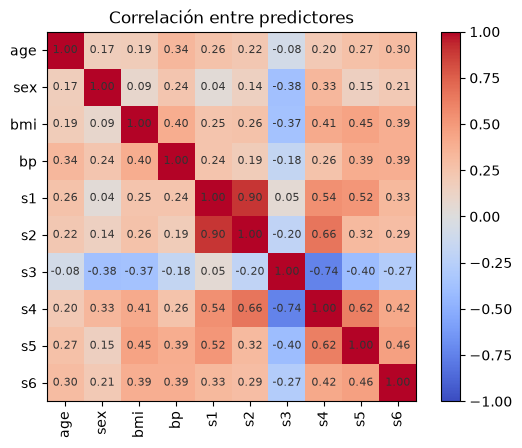

In [99]:
corr = X.corr()

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", size=8, c="0.2")

plt.title("Correlación entre predictores")
plt.show()

Se observa una **alta correlación positiva entre `s1` y `s2`** y una **alta correlación negativa entre `s3` y `s4`**. También se aprecia una correlación positiva moderada entre `s2` y `s4`. Para el resto de los pares, las correlaciones lineales son débiles o moderadas. **Sin embargo, una baja correlación entre pares de predictores no implica necesariamente ausencia de multicolinealidad**, ya que una variable puede estar fuertemente relacionada con una **combinación lineal de varias de las demás variables**, relación que no puede detectarse únicamente mediante la matriz de correlaciones por pares.

Recordemos que la **multicolinealidad puede provocar coeficientes de regresión de magnitud muy grande y altamente sensibles a pequeñas variaciones en los datos**, haciendo que las estimaciones de los coeficientes y, potencialmente, las predicciones del modelo sean inestables. Para reducir estos efectos, utilizaremos **regresión regularizada**, donde se introduce una penalización sobre la magnitud de los coeficientes con el objetivo de controlar su crecimiento y mejorar la estabilidad del modelo.

## Implementación simple


Primero implementaremos un modelo de regresion lineal sin regularización para poder observar **qué pasa con los coeficientes** cuando agregamos una penalización.

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

In [101]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

lm = LinearRegression()
lm.fit(X_train, y_train)

pd.Series(lm.coef_, index=X.columns)

age     47.749681
sex   -241.990907
bmi    531.971063
bp     381.562862
s1    -918.502905
s2     508.257783
s3     116.950164
s4     269.492303
s5     695.808117
s6      26.324582
dtype: float64

Los predictores altamente correlacionados presentan algunos de los **coeficientes de mayor magnitud**, particularmente `s1` (-918.50) y `s2` (508.26). Esto es consistente con la presencia de **multicolinealidad**, que puede producir coeficientes grandes e inestables.

Para reducir la magnitud de los coeficientes utilizaremos **Ridge Regression** como estrategia de regularización. Por el momento, utilizaremos $\alpha = 1$.

In [102]:
ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)

pd.Series(ridge.coef_, index=X.columns)

age     50.552012
sex    -67.722224
bmi    278.301228
bp     197.622638
s1      -6.245836
s2     -26.226726
s3    -151.394331
s4     120.323359
s5     215.854463
s6     101.755774
dtype: float64

Como segunda estrategia de regularización utilizaremos **Lasso Regression**, manteniendo el mismo nivel de penalización, $\alpha = 1$.

In [103]:
lasso = Lasso(alpha=1)
lasso.fit(X_train, y_train)

pd.Series(lasso.coef_, index=X.columns)

age      0.000000
sex     -0.000000
bmi    398.385831
bp      46.175421
s1       0.000000
s2       0.000000
s3      -0.000000
s4       0.000000
s5     238.187309
s6       0.000000
dtype: float64

In [104]:
coef = pd.DataFrame({
    "Variable": X.columns,
    "Lineal": lm.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

coef

,Variable,Lineal,Ridge,Lasso
0,age,47.749681,50.552012,0.000000
1,sex,-241.990907,-67.722224,-0.000000
2,bmi,531.971063,278.301228,398.385831
3,bp,381.562862,197.622638,46.175421
4,s1,-918.502905,-6.245836,0.000000
5,s2,508.257783,-26.226726,0.000000
6,s3,116.950164,-151.394331,-0.000000
7,s4,269.492303,120.323359,0.000000
8,s5,695.808117,215.854463,238.187309
9,s6,26.324582,101.755774,0.000000


La regresión **Ridge** reduce considerablemente la magnitud de los coeficientes, especialmente en variables como `s1` y `s2`, aunque mantiene todas las variables en el modelo. Por otro lado, **Lasso** lleva varios coeficientes exactamente a cero, conservando principalmente `bmi`, `bp` y `s5`. Esto muestra la diferencia fundamental entre ambas estrategias: **Ridge reduce los coeficientes, mientras que Lasso además puede realizar selección de variables**.

## Paths de regularización

Hasta ahora hemos utilizado un **coeficiente de regularización arbitrario** ($\alpha = 1$). Observemos ahora el **efecto del parámetro de regularización** sobre la magnitud de los coeficientes conforme incrementamos el valor de $\alpha$.

In [105]:
# Ajustamos regresión Ridge para cada valor de alpha

alphas = np.linspace(0, 10, 100)

ridge_coefs = []

for alpha in alphas:

    model = Ridge(alpha=alpha)
    model.fit(X, y)

    ridge_coefs.append(model.coef_)

ridge_coefs = np.array(ridge_coefs)

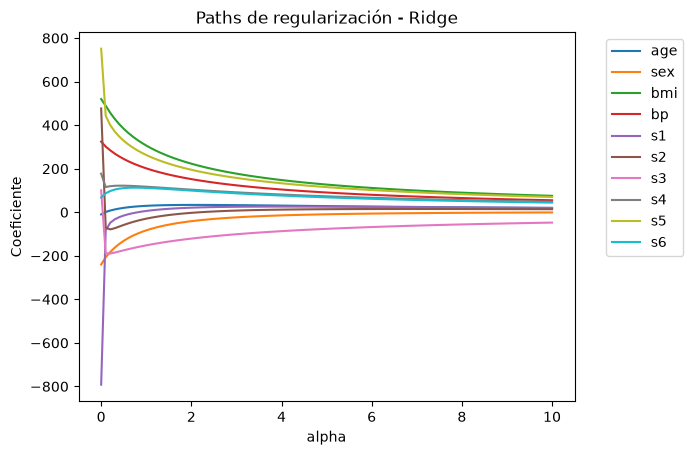

In [106]:
for i, variable in enumerate(X.columns):
    plt.plot(alphas, ridge_coefs[:, i], label=variable)

plt.xlabel("alpha")
plt.ylabel("Coeficiente")
plt.title("Paths de regularización - Ridge")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

A medida que aumenta $\lambda$, los coeficientes de **Ridge disminuyen progresivamente en magnitud y convergen hacia cero**. El efecto es especialmente notable en los coeficientes inicialmente más grandes, mostrando cómo la regularización controla estimaciones extremas. Sin embargo, **Ridge no lleva los coeficientes exactamente a cero**, sino que reduce gradualmente su contribución.

In [107]:
# Ajustamos regresión Lasso para cada valor de alpha

alphas = np.linspace(0, 3, 100)

lasso_coefs = []

for alpha in alphas:

    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X, y)

    lasso_coefs.append(model.coef_)

lasso_coefs = np.array(lasso_coefs)

c:\Users\denis\Desktop\modelado-de-datos\.venv\Lib\site-packages\sklearn\base.py:1403: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)


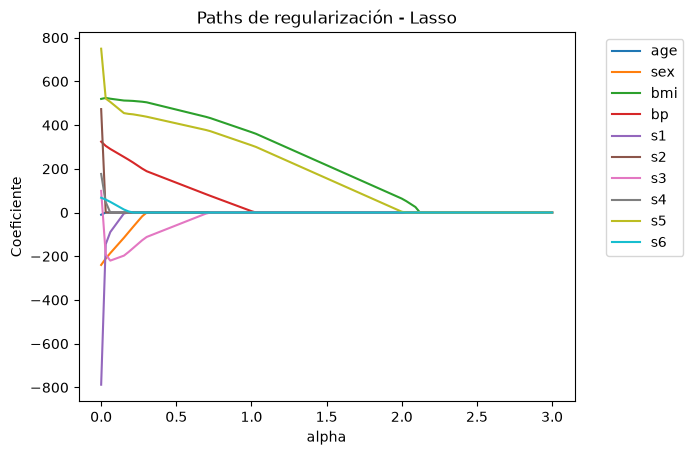

In [108]:
for i, variable in enumerate(X.columns):
    plt.plot(alphas, lasso_coefs[:, i], label=variable)

plt.xlabel("alpha")
plt.ylabel("Coeficiente")
plt.title("Paths de regularización - Lasso")

plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

A diferencia de Ridge, **Lasso puede llevar los coeficientes exactamente a cero** conforme aumenta $\lambda$, eliminando predictores del modelo. En este caso, una penalización de aproximadamente $\lambda = 2.5$ es suficiente para que **todos los coeficientes sean cero**, mostrando que una regularización excesiva puede eliminar completamente la capacidad predictiva del modelo.

## Validación cruzada

Hasta ahora elegimos $\alpha$ arbitrariamente. En un problema real, este valor debe considerarse un **hiperparámetro** y seleccionarse utilizando datos que no hayan sido utilizados para ajustar el modelo.

Para ello utilizaremos **validación cruzada**, evaluando diferentes valores de $\alpha$ y seleccionando aquel que produzca el **menor error cuadrático medio (MSE) promedio en validación**.

## Regresión Ridge

In [109]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Valores candidatos para el parámetro de regularización
alphas = np.linspace(1e-10, 1e-2, 100)

# División de los datos en 5 folds para validación cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# MSE promedio de validación para cada valor de alpha
mse_alpha = []

for alpha in alphas:

    # MSE de validación obtenido en cada fold
    mse_folds = []

    for train_idx, val_idx in kf.split(X_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Modelo Ridge con el parámetro de regularización actual
        model = Ridge(alpha=alpha)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)

        mse_folds.append(mean_squared_error(y_val, y_pred))

    # MSE promedio de los folds
    mse_alpha.append(np.mean(mse_folds))

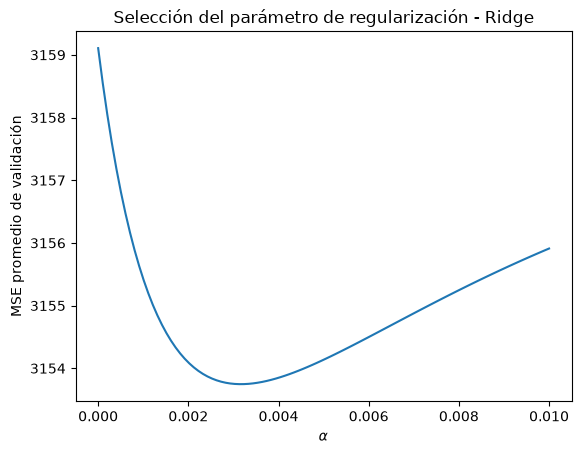

In [110]:
plt.plot(alphas, mse_alpha)

plt.xlabel(r"$\alpha$")
plt.ylabel("MSE promedio de validación")
plt.title("Selección del parámetro de regularización - Ridge")

plt.show()

Debemos seleccionar el valor de $\alpha$ que produzca el **menor MSE promedio de validación**, ya que este representa el nivel de regularización que ofrece el mejor desempeño sobre los datos de validación.

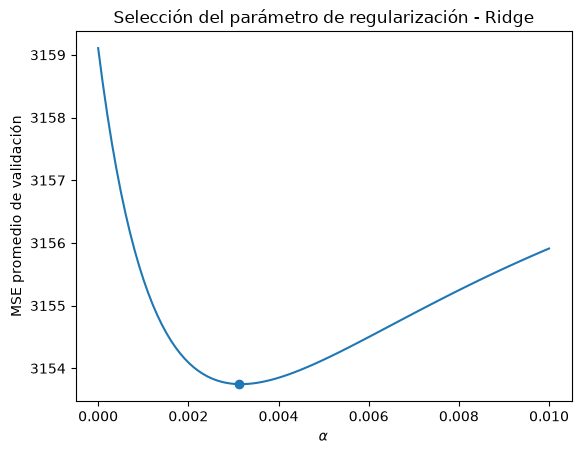

Mejor alpha: 0.0031313132000000002


In [111]:
best_alpha = alphas[np.argmin(mse_alpha)]
best_mse = np.min(mse_alpha)

plt.plot(alphas, mse_alpha)
plt.scatter(best_alpha, best_mse)

plt.xlabel(r"$\alpha$")
plt.ylabel("MSE promedio de validación")
plt.title("Selección del parámetro de regularización - Ridge")

plt.show()

print("Mejor alpha:", best_alpha)

Utilizamos el alpha con menor MSE promedio de validación para ajustar el modelo final.

In [112]:
from sklearn.metrics import mean_squared_error

ridge = Ridge(alpha=best_alpha)

ridge.fit(X_train, y_train)

pd.Series(ridge.coef_, index=X.columns)

age     49.319176
sex   -239.913799
bmi    535.350081
bp     378.381608
s1    -662.161169
s2     308.609730
s3       3.014609
s4     233.456370
s5     597.103249
s6      29.504534
dtype: float64

## Regresión Lasso

In [113]:
# Valores candidatos para el parámetro de regularización
alphas = np.linspace(1e-5, 1e-2, 100)

# División de los datos en 5 folds para validación cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# MSE promedio de validación para cada valor de alpha
mse_alpha_lasso = []

for alpha in alphas:

    # MSE de validación obtenido en cada fold
    mse_folds = []

    for train_idx, val_idx in kf.split(X_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Modelo Lasso con el parámetro de regularización actual
        model = Lasso(alpha=alpha)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)

        mse_folds.append(mean_squared_error(y_val, y_pred))

    # MSE promedio de los folds
    mse_alpha_lasso.append(np.mean(mse_folds))

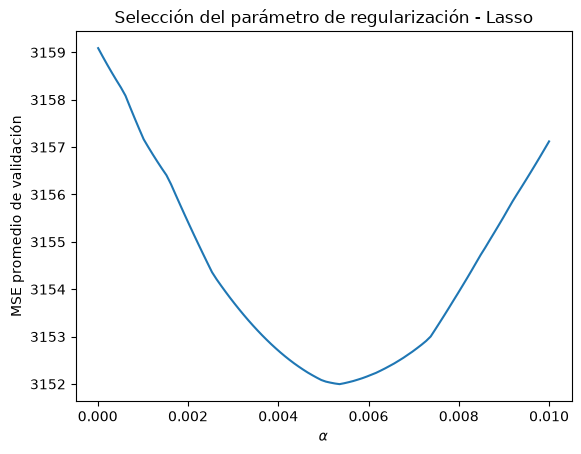

In [114]:
plt.plot(alphas, mse_alpha_lasso)

plt.xlabel(r"$\alpha$")
plt.ylabel("MSE promedio de validación")
plt.title("Selección del parámetro de regularización - Lasso")

plt.show()

In [115]:
best_alpha_lasso = alphas[np.argmin(mse_alpha_lasso)]

print("Mejor alpha:", best_alpha_lasso)

Mejor alpha: 0.005358181818181818


In [116]:
from sklearn.metrics import mean_squared_error

lasso = Lasso(alpha=best_alpha)

lasso.fit(X_train, y_train)

pd.Series(lasso.coef_, index=X.columns)

age     47.541716
sex   -239.186606
bmi    535.042278
bp     378.925752
s1    -716.899189
s2     355.941187
s3      20.338589
s4     230.394710
s5     622.336597
s6      27.003668
dtype: float64

In [117]:
# MSE de regresión lineal
mse_lineal = [
    mean_squared_error(y_train, lm.predict(X_train)),
    mean_squared_error(y_test, lm.predict(X_test))
]

# MSE de Ridge
mse_ridge = [
    mean_squared_error(y_train, ridge.predict(X_train)),
    mean_squared_error(y_test, ridge.predict(X_test))
]

# MSE de Lasso
mse_lasso = [
    mean_squared_error(y_train, lasso.predict(X_train)),
    mean_squared_error(y_test, lasso.predict(X_test))
]


# Tabla comparativa
mse_comparison = pd.DataFrame({
    "Lineal": mse_lineal,
    "Ridge": mse_ridge,
    "Lasso": mse_lasso
}, index=["Train", "Test"])

mse_comparison


,Lineal,Ridge,Lasso
Train,2907.257764,2910.084158,2909.038188
Test,2848.310651,2841.661403,2841.891798


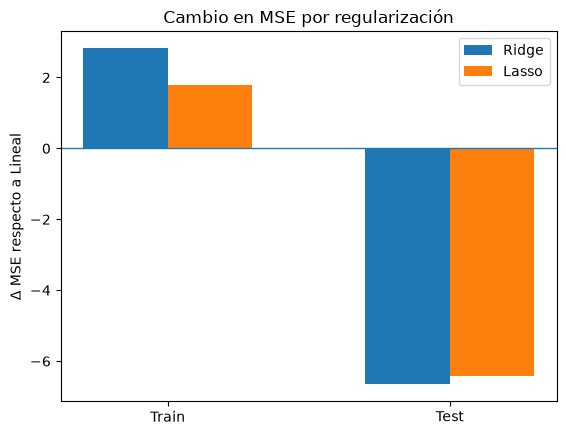

In [118]:
# Diferencia del MSE respecto a regresión lineal
delta_ridge = np.array(mse_ridge) - np.array(mse_lineal)
delta_lasso = np.array(mse_lasso) - np.array(mse_lineal)

x = np.arange(2)
w = 0.3

plt.bar(x - w/2, delta_ridge, width=w, label="Ridge")
plt.bar(x + w/2, delta_lasso, width=w, label="Lasso")

plt.axhline(0, linewidth=1)

plt.xticks(x, ["Train", "Test"])
plt.ylabel(r"$\Delta$ MSE respecto a Lineal")
plt.title("Cambio en MSE por regularización")
plt.legend()

plt.show()

La regularización **empeora ligeramente el MSE de entrenamiento**, lo que se observa como una diferencia positiva respecto al modelo lineal. Sin embargo, **mejora el MSE en datos no observados**, reflejado por una diferencia negativa. Es decir, sacrificamos parte del ajuste en entrenamiento a cambio de una **mejor capacidad de generalización**.